In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from imutils import paths
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
from torchviz import make_dot
from utils import FiSHNN, grad_cam, save_and_display_gradcam

import warnings
warnings.filterwarnings('ignore')

## FiSHNN Architecture

In [2]:
# apt-get update && apt-get install -y graphviz

# Load configuration and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

# Load label encoders
species_le = LabelEncoder()
habitat_le = LabelEncoder()

# Rename 'Scheldt' to 'SE' to match the updated naming convention
species_le.classes_ = np.array([c if c != 'Scheldt' else 'SE' for c in np.load('models/species_le.npy', allow_pickle=True)])
habitat_le.classes_ = np.array([c if c != 'Scheldt' else 'SE' for c in np.load('models/habitat_le.npy', allow_pickle=True)])

num_species = len(species_le.classes_)
num_habitats = len(habitat_le.classes_)

print(f"[INFO] Species classes: {species_le.classes_}")
print(f"[INFO] Habitat classes: {habitat_le.classes_}")

# Load FiSHNN model
model = FiSHNN(num_species=num_species, num_habitats=num_habitats).to(device)
model_state = torch.load('models/FiSHNN_best.pt', map_location=device)
model.load_state_dict(model_state)
model.eval()

# Create output directory
os.makedirs('./Figs', exist_ok=True)

# Visualize model architecture using torchviz
dummy_input = torch.randn(1, 3, 256, 256).to(device)
species_out, habitat_out = model(dummy_input)

# Create computation graph
dot = make_dot((species_out, habitat_out), params=dict(model.named_parameters()), show_attrs=False, show_saved=False)
dot.format = 'png'
dot.render('./Figs/Figure_S0_FiSHNN_architecture', cleanup=True)

[INFO] Using device: cuda
[INFO] Species classes: ['AF' 'AM' 'AT' 'CH' 'HL' 'SS']
[INFO] Habitat classes: ['BCS' 'DCS' 'SE']


'Figs/Figure_S0_FiSHNN_architecture.png'

## t-SNE Visualization

In [3]:
# Extract features from the last layers of species and habitat branches
imagePaths = sorted(list(paths.list_images("otolith_dataset")))

# Lists to store extracted features
species_features = []
habitat_features = []
species_labels = []
habitat_labels = []

# Process each image and extract features
model.eval()
with torch.no_grad():
    for idx, imagePath in enumerate(imagePaths):
        if idx % 100 == 0:
            print(f"  Processing {idx}/{len(imagePaths)}...")
        
        # Load and preprocess image
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (256, 256))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype("float32") / 255.0
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device)
        
        # Get logits from both branches
        species_logit, habitat_logit = model(image_tensor)
        
        # Store features (logits from final layer)
        species_features.append(species_logit.cpu().numpy())
        habitat_features.append(habitat_logit.cpu().numpy())
        
        # Extract labels from path
        (spe, loc) = imagePath.split(os.path.sep)[-2].split('_')
        
        # Map 'Scheldt' to 'SE' to match the label encoder
        spe = 'SE' if spe == 'Scheldt' else spe
        loc = 'SE' if loc == 'Scheldt' else loc
        
        species_labels.append(spe)
        habitat_labels.append(loc)

# Convert to numpy arrays
species_features = np.array(species_features).squeeze()  # (n_samples, num_species)
habitat_features = np.array(habitat_features).squeeze()  # (n_samples, num_habitats)
species_labels_encoded = species_le.transform(species_labels)
habitat_labels_encoded = habitat_le.transform(habitat_labels)

print(f"[INFO] Extracted features: species {species_features.shape}, habitat {habitat_features.shape}")

  Processing 0/1389...
  Processing 100/1389...
  Processing 200/1389...
  Processing 300/1389...
  Processing 400/1389...
  Processing 500/1389...
  Processing 600/1389...
  Processing 700/1389...
  Processing 800/1389...
  Processing 900/1389...
  Processing 1000/1389...
  Processing 1100/1389...
  Processing 1200/1389...
  Processing 1300/1389...
[INFO] Extracted features: species (1389, 6), habitat (1389, 3)


In [4]:
# Perform t-SNE dimensionality reduction
tsne_species = TSNE(n_components=2, random_state=42)
tsne_habitat = TSNE(n_components=2, random_state=42)

species_tsne = tsne_species.fit_transform(species_features)
habitat_tsne = tsne_habitat.fit_transform(habitat_features)

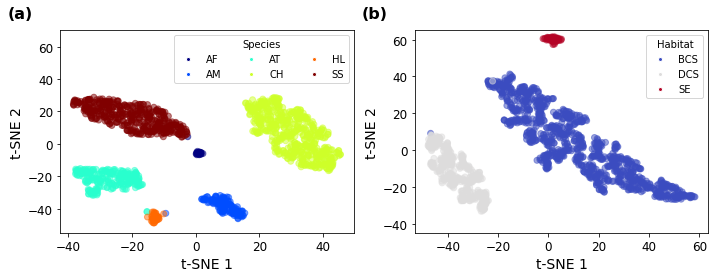

In [5]:
# Plot t-SNE results with same style as v1.1.ipynb
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot t-SNE results for species
scatter1 = ax[0].scatter(species_tsne[:, 0], species_tsne[:, 1], c=species_labels_encoded, cmap='jet', alpha=0.5)
ax[0].set_ylim(-55, 70)                        
ax[0].set_xlabel('t-SNE 1', fontsize=14)
ax[0].set_ylabel('t-SNE 2', fontsize=14)
ax[0].tick_params(axis='both', labelsize=12)

# Create legend for species classes
handles1 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter1.cmap(scatter1.norm(i)), markersize=4) for i in range(len(species_le.classes_))]
ax[0].legend(handles1, species_le.classes_, title="Species", loc='upper right', fontsize=10, ncol=3)
ax[0].text(-0.18, 1.12, '(a)', transform=ax[0].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')


# Plot t-SNE results for habitat
scatter2 = ax[1].scatter(habitat_tsne[:, 0], habitat_tsne[:, 1], c=habitat_labels_encoded, cmap='coolwarm', alpha=0.5)
ax[1].set_ylim(-45, 65)    
ax[1].set_xlabel('t-SNE 1', fontsize=14)
ax[1].set_ylabel('t-SNE 2', fontsize=14)
ax[1].tick_params(axis='both', labelsize=12)

# Create legend for habitat classes
handles2 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter2.cmap(scatter2.norm(i)), markersize=4) for i in range(len(habitat_le.classes_))]
ax[1].legend(handles2, habitat_le.classes_, title="Habitat", loc='upper right', fontsize=10)
ax[1].text(-0.18, 1.12, '(b)', transform=ax[1].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')

plt.tight_layout()
fig.savefig('./Figs/Figure_5_t-SNE.pdf')
fig.savefig('./Figs/Figure_5_t-SNE.png', dpi=600, bbox_inches='tight')

## Grad-CAM Visualization

In [6]:
# Generate Grad-CAM for example images
print("\n[INFO] Generating Grad-CAM visualizations...")

imagePaths_exp = sorted(list(paths.list_images("otolith_examples/Origin")))

# Create output directories
os.makedirs('./otolith_examples/CAM_species_FiSHNN', exist_ok=True)
os.makedirs('./otolith_examples/CAM_habitat_FiSHNN', exist_ok=True)

model.eval()
for imagePath in imagePaths_exp:
    # Load and preprocess image
    image = cv2.imread(imagePath)
    image_resized = cv2.resize(image, (256, 256))
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_normalized = image_rgb.astype("float32") / 255.0
    image_tensor = torch.from_numpy(image_normalized).permute(2, 0, 1).unsqueeze(0).to(device)
    
    # Predict the species and habitat labels
    with torch.no_grad():
        species_logit, habitat_logit = model(image_tensor)
        species_class = species_logit.argmax(dim=1).item()
        habitat_class = habitat_logit.argmax(dim=1).item()
    
    # Generate Grad-CAM for species branch
    # Target: last conv layer (features[5] is the last MBConv block in the branch)
    species_heatmap = grad_cam(model, image_tensor, species_class, branch="species", target_layer="auto")
    
    # Generate Grad-CAM for habitat branch
    # Target: last conv layer (features[5] is the last MBConv block in the branch)
    habitat_heatmap = grad_cam(model, image_tensor, habitat_class, branch="habitat", target_layer="auto")
    
    # Save Grad-CAM results
    basename = os.path.basename(imagePath)
    save_and_display_gradcam(imagePath, species_heatmap[0], cam_path=f"./otolith_examples/CAM_species_FiSHNN/{basename}")
    save_and_display_gradcam(imagePath, habitat_heatmap[0], cam_path=f"./otolith_examples/CAM_habitat_FiSHNN/{basename}")



[INFO] Generating Grad-CAM visualizations...


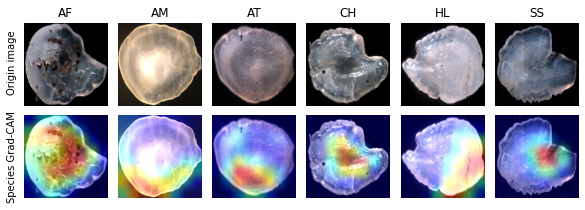

In [7]:
# Visualize Species branch Grad-CAM
imagePaths_exp_spe = sorted(list(paths.list_images("./otolith_examples/CAM_species_FiSHNN/")))

fig, ax = plt.subplots(2, 6, figsize=(8, 3))
for idx, imagePath in enumerate(imagePaths_exp_spe):
    basename = os.path.basename(imagePath)
    
    # Original image
    img_origin = cv2.resize(cv2.imread(f'./otolith_examples/Origin/{basename}'), (256, 256))
    ax[0, idx].imshow(cv2.cvtColor(img_origin, cv2.COLOR_BGR2RGB))
    ax[0, idx].axis('off')
    
    # Map title and replace 'Scheldt' with 'SE'
    title = basename.split('-')[0]
    title = 'SE' if title == 'Scheldt' else title
    ax[0, idx].set_title(title)
    
    # Grad-CAM image
    img_cam_spe = cv2.resize(cv2.imread(imagePath), (256, 256))
    ax[1, idx].imshow(cv2.cvtColor(img_cam_spe, cv2.COLOR_BGR2RGB))
    ax[1, idx].axis('off')

fig.text(-0.01, 0.70, 'Origin image', va='center', rotation=90, fontsize=10)
fig.text(-0.01, 0.26, 'Species Grad-CAM', va='center', rotation=90, fontsize=10)

plt.tight_layout()
plt.savefig('./Figs/Figure_6a_Species_Grad-CAM.pdf')
plt.savefig('./Figs/Figure_6a_Species_Grad-CAM.png', dpi=600, bbox_inches='tight')

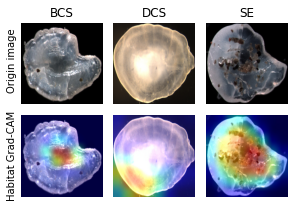

In [8]:
# Visualize Habitat branch Grad-CAM
imagePaths_exp_hab = sorted(list(paths.list_images("./otolith_examples/CAM_habitat_FiSHNN/")))
jdx = 2

fig, ax = plt.subplots(2, 3, figsize=(4, 3))
for idx, imagePath in enumerate(imagePaths_exp_hab):
    if idx in [3, 1, 0]:  # Select specific indices for display
        basename = os.path.basename(imagePath)
        
        # Original image
        img_origin = cv2.resize(cv2.imread(f'./otolith_examples/Origin/{basename}'), (256, 256))
        ax[0, jdx].imshow(cv2.cvtColor(img_origin, cv2.COLOR_BGR2RGB))
        ax[0, jdx].axis('off')
        
        # Map title and replace 'Scheldt' with 'SE'
        title = os.path.splitext(basename.split('-')[1])[0]
        title = 'SE' if title == 'Scheldt' else title
        ax[0, jdx].set_title(title)
        
        # Grad-CAM image
        img_cam_hab = cv2.resize(cv2.imread(imagePath), (256, 256))
        ax[1, jdx].imshow(cv2.cvtColor(img_cam_hab, cv2.COLOR_BGR2RGB))
        ax[1, jdx].axis('off')
        jdx -= 1

fig.text(-0.01, 0.70, 'Origin image', va='center', rotation=90, fontsize=10)
fig.text(-0.01, 0.26, 'Habitat Grad-CAM', va='center', rotation=90, fontsize=10)

plt.tight_layout()
plt.savefig('./Figs/Figure_6b_Habitat_Grad-CAM.pdf')
plt.savefig('./Figs/Figure_6b_Habitat_Grad-CAM.png', dpi=600, bbox_inches='tight')